In [5]:
import pandas as pd

# Criação do DataFrame

def carregar_biblioteca_antoine(Tabela_csv):
    df = pd.read_csv(Tabela_csv, sep=';')

    # Tratamento da Base de dados:

    # corrigir nomes de colune
    df = df.rename(columns={
        'Composto': 'composto',
        'Ant(A)': 'A',
        'Ant(B)': 'B',
        'Ant(C)': 'C',
        'Max': 'Tmax',
        'Min': 'Tmin'
    })

    # corrigir a pontuação (vírgula para ponto)

    colunas = ['A', 'B', 'C', 'Tmax', 'Tmin']
    for col in colunas:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # tira linha em branco
    df = df.dropna(subset=['A', 'B', 'C'])

    # tira as duplicadas
    df = df.drop_duplicates(subset='composto')

    return df
df = carregar_biblioteca_antoine('../dados/Constantes_Antoine_corrigido.csv')

biblioteca = df.set_index('composto')[['A', 'B', 'C', 'Tmax', 'Tmin']]

print(biblioteca)

                               A        B       C   Tmax   Tmin
composto                                                       
Argon                    15.2330   700.51   -5.84   94.0   81.0
Bromide                  15.8441  2582.32  -51.56  354.0  259.0
Nitrosyl Cloride         16.9505  2520.70  -23.46  285.0  210.0
Chloride                 15.9610  1978.32  -27.01  264.0  172.0
Silicon Tetrachloride    15.8019  2634.16  -43.15  364.0  238.0
...                          ...      ...     ...    ...    ...
n-nonadecane             16.1533  4450.44 -135.60  639.0  456.0
n-pentadecycyclopentane  16.3092  4642.01 -145.10  661.0  476.0
n-eicosane               16.4685  4680.46 -141.10  652.0  471.0
1-eiconasol              15.8233  3912.10 -203.10  679.0  492.0
n-hexadecycyclopentane   16.3553  4715.69 -152.10  674.0  488.0

[437 rows x 5 columns]


In [6]:
composto = 'Argon'

A, B, C, Tmin, Tmax = biblioteca.loc[composto, ['A', 'B', 'C', 'Tmin', 'Tmax']]

print(f"Constantes de Antoine - {composto}")
print(f"A = {A:.4f}")
print(f"B = {B:.4f}")
print(f"C = {C:.4f}")
print(f"Tmin = {Tmin:.1f}")
print(f"Tmax = {Tmax:.1f}")

print("\nEquação:")
# está erradoooo, usar ln
print("np.exp(A - B / (T + C))" \
")")

Constantes de Antoine - Argon
A = 15.2330
B = 700.5100
C = -5.8400
Tmin = 81.0
Tmax = 94.0

Equação:
np.exp(A - B / (T + C)))


In [ ]:
import numpy as np

# Retorna pressão de vapor em mmHg dado T em K
def P_sat(composto, T, biblioteca):
    dados = biblioteca.loc[composto]
    A, B, C = dados['A'], dados['B'], dados['C']
    return np.exp(A - B / (T + C))

# composto = 'Argon' - sem a criação de vinculo com o bloco de definição de composto 
# fazer alteração para criar vínculo 


P = P_sat(composto, 120, biblioteca)
# ao dividir por 7,501 garanto que minha pressão de saturação está em Bar
P_kPa = P /750.1

print(f"{composto}: {P_kPa:.2f} Bar")

Argon: 11.90 Bar


a2)- faça um código que solicite a maior e menor temperatura e grafique P vs T, coloque lendas, nomes rótulos ,etc


Faixa válida: 81.0 até 94.0 °C


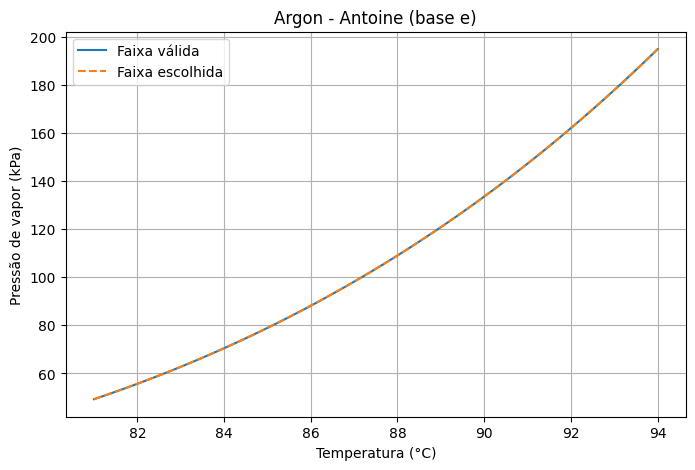

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def pressao_vapor(T, composto, biblioteca):
    A, B, C = biblioteca.loc[composto, ['A', 'B', 'C']]
   # A_ln = A * np.log(10)
   # B_ln = B * np.log(10)
   # cálculo usando Ln
    return np.exp(A - B / (T + C))

if composto not in biblioteca.index:
    print("Defina primeiro um composto válido no bloco 1.")
else:
    
    Tmin_tab = biblioteca.loc[composto, "Tmin"]
    Tmax_tab = biblioteca.loc[composto, "Tmax"]

    print(f"Faixa válida: {Tmin_tab} até {Tmax_tab} °C")

    Tmin_input = float(input("Digite a temperatura mínima desejada (°C): "))
    Tmax_input = float(input("Digite a temperatura máxima desejada (°C): "))


    T_tab = np.linspace(Tmin_tab, Tmax_tab, 100)
    P_tab = pressao_vapor(T_tab, composto, biblioteca) * 0.133322

    T_user = np.linspace(Tmin_input, Tmax_input, 100)
    P_user = pressao_vapor(T_user, composto, biblioteca) * 0.133322

    plt.figure(figsize=(8, 5))
    plt.plot(T_tab, P_tab, label="Faixa válida")
    plt.plot(T_user, P_user, linestyle='--', label="Faixa escolhida")

    plt.xlabel("Temperatura (°C)")
    plt.ylabel("Pressão de vapor (kPa)")
    plt.title(f"{composto} - Antoine (base e)")
    plt.legend()
    plt.grid(True)
    plt.show()

a3)- mostre seu código comparando graficamente [matplotlib] os seguintes  compostos, discuta suas observações.

Methane: Pmin = 24244684.95 kPa
Ethane: Pmin = 24.78 kPa
Propane: Pmin = 23.14 kPa
n-butane: Pmin = 24.19 kPa
n-pentane: Pmin = 15.90 kPa
n-hexane: Pmin = 16.37 kPa


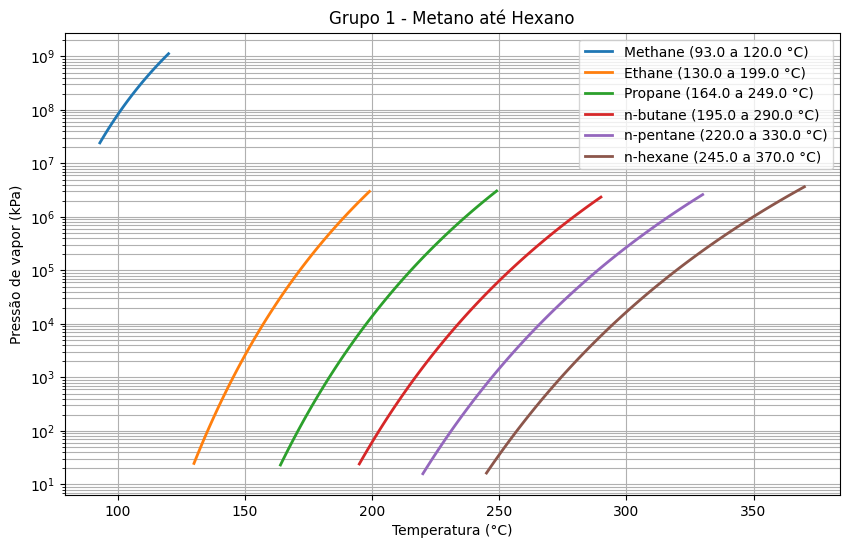

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def pressao_vapor(T, composto, biblioteca):
    A, B, C = biblioteca.loc[composto, ['A', 'B', 'C']]
    A_ln = A * np.log(10)
    B_ln = B * np.log(10)
    return np.exp(A_ln - B_ln / (T + C))

def comparar_compostos(compostos, biblioteca, titulo):
    plt.figure(figsize=(10, 6))

    for composto in compostos:
        if composto not in biblioteca.index:
            print(f"{composto} não encontrado na biblioteca.")
            continue

        Tmin = biblioteca.loc[composto, 'Tmin']
        Tmax = biblioteca.loc[composto, 'Tmax']

        T = np.linspace(Tmin, Tmax, 100)
        P_mmHg = pressao_vapor(T, composto, biblioteca)
        P_kPa = P_mmHg * 0.133322

        print(f"{composto}: Pmin = {np.min(P_kPa):.2f} kPa")

        plt.plot(T, P_kPa, linewidth=2, label=f"{composto} ({Tmin:.1f} a {Tmax:.1f} °C)")

    plt.xlabel("Temperatura (°C)")
    plt.ylabel("Pressão de vapor (kPa)")
    plt.title(titulo)
    plt.yscale('log')
    plt.legend()
    plt.grid(True, which='both')
    plt.show()

grupo_1 = ['Methane', 'Ethane', 'Propane', 'n-butane', 'n-pentane', 'n-hexane']
comparar_compostos(grupo_1, biblioteca, "Grupo 1 - Metano até Hexano")

In [10]:
# CÉLULA 1 - funções

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def carregar_base(csv_path="Constantes_Antoine_corrigido.csv"):
    df = pd.read_csv(csv_path, sep=";")
    df = df.rename(columns={
        "Composto": "composto",
        "Formula": "formula",
        "Ant(A)": "A",
        "Ant(B)": "B",
        "Ant(C)": "C",
        "Max": "Tmax",
        "Min": "Tmin",
    })

    for col in ["A", "B", "C", "Tmax", "Tmin"]:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ".", regex=False), errors="coerce")

    df = df.dropna(subset=["A", "B", "C", "Tmin", "Tmax"])
    df["formula"] = df["formula"].astype(str).str.strip()
    df["composto"] = df["composto"].astype(str).str.strip()
    return df

def antoine_ln_mmHg(T_K, A, B, C):
    return np.exp(A - B / (T_K + C))

def resolver_composto(df, item):
    key = item.strip().upper()
    preferencia_formula = {"C3H6": "Propylene", "C8H10": "p-xylene", "CO2": "Carbon dioxide"}

    if key == "CO":
        m = df[df["composto"].str.lower() == "carbon monoxide"]
        if len(m): return m.iloc[0], "CO (mapeado para Carbon Monoxide; fórmula na base está como CO2)"
        return None, "CO (não encontrado)"

    if key == "H2SO4":
        m = df[df["composto"].str.lower().str.contains("sulfuric", na=False)]
        if len(m): return m.iloc[0], "H2SO4"
        return None, "H2SO4 (não encontrado na base)"

    m = df[df["formula"].str.upper() == key]
    if len(m):
        pref = preferencia_formula.get(key)
        if pref:
            p = m[m["composto"].str.lower() == pref.lower()]
            if len(p): return p.iloc[0], pref
        if key == "C8H10":
            x = m[m["composto"].str.lower().str.contains("xylene", na=False)]
            if len(x): return x.iloc[0], x.iloc[0]["composto"]
        return m.iloc[0], m.iloc[0]["composto"]

    m = df[df["composto"].str.lower() == item.strip().lower()]
    if len(m): return m.iloc[0], m.iloc[0]["composto"]

    m = df[df["composto"].str.lower().str.contains(item.strip().lower(), na=False)]
    if len(m): return m.iloc[0], m.iloc[0]["composto"]

    return None, f"{item} (não encontrado)"

def plotar_grupo(ax, df, titulo, itens, T_C_min=None, T_C_max=None):
    if T_C_min is None: T_C_min = -150.0
    if T_C_max is None: T_C_max = 450.0

    T_C = np.linspace(T_C_min, T_C_max, 500)
    T_K = T_C + 273.15
    observacoes = []
    plotted_any = False

    for item in itens:
        row, label = resolver_composto(df, item)
        if row is None:
            observacoes.append(f"- {label}")
            continue

        A, B, C = float(row["A"]), float(row["B"]), float(row["C"])
        Tmin_K, Tmax_K = float(row["Tmin"]), float(row["Tmax"])
        Tmin_C, Tmax_C = Tmin_K - 273.15, Tmax_K - 273.15

        P_mmHg = antoine_ln_mmHg(T_K, A, B, C)
        P_bar = P_mmHg * 0.00133322
        valido = (T_K >= Tmin_K) & (T_K <= Tmax_K)

        if np.any(valido):
            ax.plot(T_C[valido], P_bar[valido], lw=2, label=f"{label}")
            plotted_any = True
        if np.any(~valido):
            ax.plot(T_C[~valido], P_bar[~valido], lw=1.2, ls="--", alpha=0.45)

        observacoes.append(f"- {label}: faixa válida {Tmin_C:.1f} a {Tmax_C:.1f} °C")

    ax.set_title(titulo)
    ax.set_xlabel("Temperatura (°C)")
    ax.set_ylabel("Pressão de vapor (bar)")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.25)

    if plotted_any:
        ax.legend(fontsize=8, loc="best")
    else:
        ax.text(0.03, 0.95, "Sem dados na faixa válida\n(apenas extrapolação)",
                transform=ax.transAxes, va="top", fontsize=8,
                bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "none"})

    return observacoes


In [ ]:
# CÉLULA 2 - execução dos 7 grupos

df = carregar_base("Constantes_Antoine_corrigido.csv")

grupos = [
    ("Grupo 1: C1 a C6", ["CH4", "C2H6", "C3H8", "C4H10", "C5H12", "C6H14"], None, None),
    ("Grupo 2: Reforming", ["CO", "CO2", "CH4", "H2", "H2O"], None, None),
    ("Grupo 3: Andrussow", ["CH4", "NH3", "O2", "HCN", "H2O"], 0, 1200),
    ("Grupo 4: Sistema S", ["H2O", "O2", "SO2", "SO3", "H2SO4"], None, None),
    ("Grupo 5: C3H8, C3H6, H2", ["C3H8", "C3H6", "H2"], 500, 680),
    ("Grupo 6: BTX", ["C6H6", "C7H8", "C8H10"], None, None),
    ("Grupo 7: Benzeno, Hexano, H2", ["C6H6", "C6H14", "H2"], None, None),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

todas_obs = {}
for i, (titulo, itens, tmin, tmax) in enumerate(grupos):
    todas_obs[titulo] = plotar_grupo(axes[i], df, titulo, itens, tmin, tmax)

fig.delaxes(axes[-1])  # remove subplot vazio
fig.suptitle("Comparação de Pressão de Vapor por Antoine (escala log)", fontsize=14)
fig.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

print("Resumo de disponibilidade/faixas:")
for g, obs in todas_obs.items():
    print(f"\n{g}")
    for o in obs:
        print(o)
